# Step 3: Mask creation

Now we have rain rate for the entire domain - we need to subselect data using masks for Fig6 and Fig7.

**Fig 6 masks**
- Only needed for Townsville and Cairns
- 3 masks:
	- Beam blockage
	- Land mask
	- Ocean mask

**Fig 7 masks**
- Only for Cairns and Willis
- 2 masks:
 	- Beam blockage for Cairns
	- Lat slice mask

In [1]:
import numpy as np
import xarray as xr
import dask.array as da
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import sys
import metpy
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import metpy.calc as mpcalc
import pandas as pd
from netCDF4 import Dataset
import pyproj
import os
import glob
from datetime import datetime
import seaborn as sns
import netCDF4
from netCDF4 import Dataset
from metpy.units import units
import dask
import xarray as xr
from shapely import Polygon
import regionmask
import geopandas as gpd
import logging
import dask
from dask.distributed import Client
from dask import delayed
import functools
import zipfile
import tempfile
import wradlib as wrl
sys.path.append(os.path.join(r"/home/563/ac9768/GBR/scripts/Paper_figures")) 
%load_ext autoreload
%autoreload 2

In [2]:
from dask_setup import setup_dask_client 
from dask_setup import recommend_chunks
client, cluster, dask_tmp = setup_dask_client(mode="interactive", workload_type="cpu") # 'io','mixed'(io and cpu=computation), 'auto' (inferred from ds)

INFO     [client] Interactive cluster mode — using already-allocated nodes
INFO     [multinode] Interactive cluster: single node, using LocalCluster (node=gadi-cpu-bdw-0099.gadi.nci.org.au)
INFO     [client] Starting Dask client setup (workload_type=cpu | environment=jupyter)
INFO     [resources] Resources detected via PBS (total_cores=28 | total_mem_gib=252.0)


INFO     [client] Temp/spill dir: /jobfs/168313098.gadi-pbs/dask-543896
INFO     [client] Workers: 28 | threads/worker: 1 | processes: True
INFO     [client] Mem: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~7.2 GiB
INFO     [client] Compression: spill=auto | comm=False
INFO     [client] Dask client ready


[setup_dask_client] Configuration summary
temp/spill dir: /jobfs/168313098.gadi-pbs/dask-543896
Workers: 28 | threads/worker: 1 | processes: True
Memory: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~7.2 GiB
Compression: spill=auto | comm=False


In [3]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/44493/status,
Dashboard: /proxy/44493/status,Workers: 28
Total threads: 28,Total memory: 202.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35245,Workers: 0
Dashboard: /proxy/44493/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38383,Total threads: 1
Dashboard: /proxy/36525/status,Memory: 7.21 GiB
Nanny: tcp://127.0.0.1:43741,


# Define site

In [4]:
site = "towns"

# Beam blockage mask (Towns & Cairns)

In [5]:
# open data
site_fp = f'/scratch/v46/ac9768/radar/{site}_rainrate.zarr'
# ds = xr.open_zarr(site_fp, chunks='auto')
ds = xr.open_zarr(site_fp,chunks={'time': 186}) #.drop_vars(['lat','lon'])
# recommend_chunks(ds)

/jobfs/168313098.gadi-pbs/ipykernel_543896/2309620396.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 186. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(site_fp,chunks={'time': 186})#.drop_vars(['lat','lon'])


In [ ]:
# create bb mask and plot to check
if site == 'cairns':
    print('computing cairns bb mask ...')
    # --- compute azimuth grid (numpy, small) ---
    x = ds['x'].values
    y = ds['y'].values
    xx, yy = np.meshgrid(x, y)
    az_bins   = np.arange(0, 361, 1)
    az_labels = az_bins[:-1]  # 0..359
    az_grid = np.degrees(np.arctan2(xx, yy)) % 360
    az_binned = (az_labels[np.digitize(az_grid, az_bins) - 1]).astype(int)  # (y, x) numpy
    
    # --- time-mean as dask array ---
    rr_mean = ds['rainrate'].mean(dim='time')  # stays lazy (y, x)
    
    # --- compute per-azimuth mean using dask ---
    def az_sector_mask(rr_mean_np, az_binned, n_az=360, window=16):# for cairns):
        """For each pixel, compute rolling median of azimuth-mean and return threshold."""
        az_means = np.zeros(n_az)
        for i in range(n_az):
            vals = rr_mean_np[az_binned == i]
            az_means[i] = np.nanmean(vals) if len(vals) > 0 else np.nan
    
        # rolling median over azimuths
        from scipy.ndimage import uniform_filter1d
        rolling = np.array([
            np.nanmedian(np.roll(az_means, -window//2 + j)[:window])
            for j in range(n_az)
        ])
    
        # map threshold back to 2D
        threshold_2d = rolling[az_binned]
        return threshold_2d
    
    # compute threshold (small — just 2D numpy)
    rr_mean_np = rr_mean.compute().values
    threshold_2d = az_sector_mask(rr_mean_np, az_binned)
    threshold_da = xr.DataArray(threshold_2d, dims=['y', 'x'], coords={'y': ds.y, 'x': ds.x})
    rr_mean_da   = xr.DataArray(rr_mean_np,   dims=['y', 'x'], coords={'y': ds.y, 'x': ds.x})
    
    # --- apply mask lazily to full time series ---
    ds['rainrate_bb'] = ds['rainrate'].where(rr_mean_da > 0.5 * threshold_da)
    
    # --- plot single timestep ---
    ds['rainrate_bb'].mean('time').plot(cmap='viridis')
    plt.title('Rain rate — beam blockage masked')
    plt.show()
elif site =='towns':
    print('computing towns bb mask ...')
    mean = ds.rainrate.mean('time').compute()
    mask = (mean > 0.06).compute()
    masked_ds = mean.where(mask)
    masked_ds.plot()
    plt.show()
else:
    print('No beam blockage mask needed for willis island')

computing towns bb mask ...


2026-05-14 13:27:52,623 - distributed.protocol.core - CRITICAL - Failed to deserialize
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/distributed/protocol/core.py", line 175, in loads
    return msgpack.loads(
           ^^^^^^^^^^^^^^
  File "msgpack/_unpacker.pyx", line 194, in msgpack._cmsgpack.unpackb
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/distributed/protocol/core.py", line 172, in _decode_default
    return pickle.loads(sub_header["pickled-obj"], buffers=sub_frames)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/distributed/protocol/pickle.py", line 95, in loads
    return pickle.loads(x)
           ^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/sitecustomize.py", line 72

In [21]:
# save mask as nc
if site == 'cairns':
    mask_ds = ds.copy().drop_vars(['rainrate','rainrate_bb'])
    mask = rr_mean_da > 0.5 * threshold_da
    mask_ds['blockage_mask'] = mask
    mask_ds['lat'] = mask_ds.lat.isel(time=0).drop_vars('time')
    mask_ds['lon'] = mask_ds.lon.isel(time=0).drop_vars('time')
    mask_ds.to_netcdf(f'/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bb_mask_{site}.nc')
elif site == 'towns':
    mask.to_netcdf(f'/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bb_mask_{site}.nc')
else:
    print('No willis island mask')

### Fig7 Cairns beam blockage & lat mask

In [11]:
if site=="cairns":
    mask_ds = ds.copy().drop_vars(['rainrate','rainrate_bb'])
    mask = rr_mean_da > 0.5 * threshold_da
    mask_ds['blockage_mask'] = mask
    mask_ds['lat'] = mask_ds.lat.isel(time=0).drop_vars('time')
    mask_ds['lon'] = mask_ds.lon.isel(time=0).drop_vars('time')
    
    mask_lat = (mask_ds.lat > -17) & (mask_ds.lat < -16.6)
    mask_lat_ds = mask_ds.blockage_mask.where(mask_lat,0)
    mask_lat_ds.plot()
    mask_lat_ds.to_netcdf(f'/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDlat_mask_{site}.nc')

### Fig7 Willis lat mask

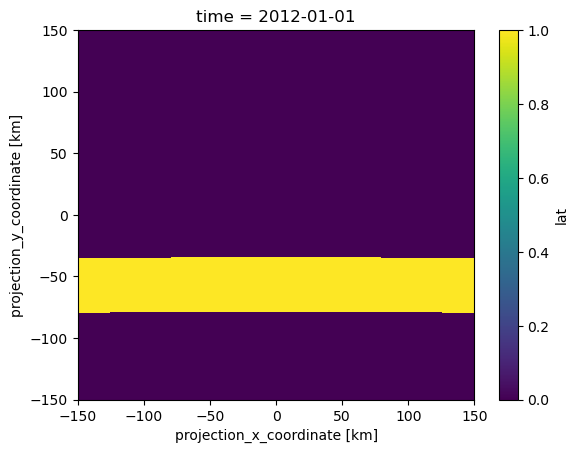

In [13]:
if site=="willis":
    mask_lat = (ds.isel(time=0).lat > -17) & (ds.isel(time=0).lat < -16.6)
    mask_lat.plot()
    mask_lat.to_netcdf(f'/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/lat_mask_{site}.nc')

# Fig 6 land & ocean masks

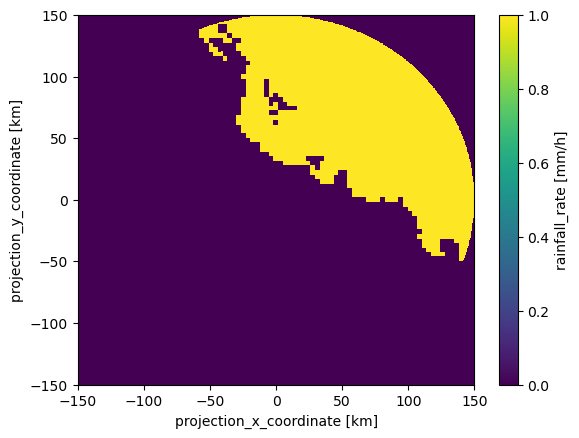

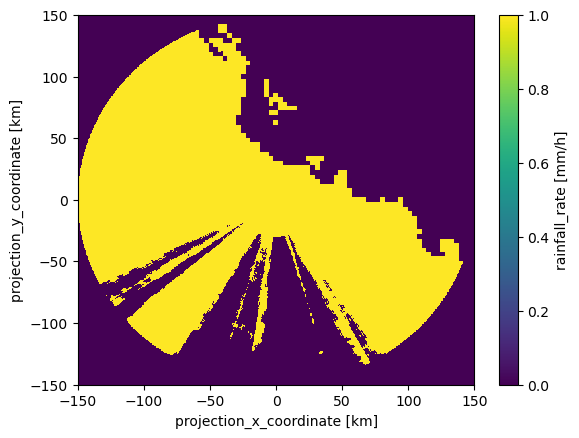

In [22]:
# open bathymetry dataset
if site == 'cairns' or site == 'towns':
    ds_full = xr.open_dataset('/home/563/ac9768/GBR/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part',engine="netcdf4")
    ds_bath = ds_full.sel(x=slice(140,155),y=slice(-22,-11))
    
    lon2d = ds.isel(time=0).drop_vars('time').lon.compute()  # (y, x)
    lat2d = ds.isel(time=0).drop_vars('time').lat.compute()  # (y, x)
    
    # nearest neighbour lookup on bathymetry grid for each (lat, lon) point
    bathymetry = ds_bath["z"].sel(
        x=xr.DataArray(lon2d.values, dims=['y', 'x']),
        y=xr.DataArray(lat2d.values, dims=['y', 'x']),
        method="nearest"
    )
    try:
        mask_bb = xr.open_dataset(f'/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bb_mask_{site}.nc').blockage_mask.drop_vars(['lat','lon'])
    except:
        mask_bb = xr.open_dataset(f'/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bb_mask_{site}.nc').rainrate
    
    land_mask = bathymetry<=0  # mask land pixels (True=ocean)
    ocean_mask = bathymetry>0  # mask ocean pixels (True=land)
    if site=="cairns":
        maskx = ds.x>-145.75
        land_mask_ = (mask_bb) & (maskx) & (land_mask) 
        ocean_mask_ = (mask_bb) & (maskx) & (ocean_mask) 
    else:
        land_mask_ = (mask_bb) & (land_mask) 
        ocean_mask_ = (mask_bb) & (ocean_mask)
    
    land_mask_.to_netcdf(f'/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDland_mask_{site}.nc') # to mask land
    ocean_mask_.to_netcdf(f'/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDocean_mask_{site}.nc') # to mask ocean
    land_mask_.plot()
    plt.show()
    ocean_mask_.plot()
    plt.show()
else:
    print('No land/ocean masks needed for Willis Island')

In [25]:
# open masks to check
try:
    mask_land = xr.open_dataset(f'/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDland_mask_{site}.nc').blockage_mask.drop_vars(['lat','lon'])
    mask_ocean = xr.open_dataset(f'/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDocean_mask_{site}.nc').blockage_mask.drop_vars(['lat','lon'])
except:
    mask_land = xr.open_dataset(f'/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDland_mask_{site}.nc')
    mask_ocean = xr.open_dataset(f'/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDocean_mask_{site}.nc')
mask_ocean

<xarray.Dataset> Size: 370kB
Dimensions:                        (y: 600, x: 600)
Coordinates:
  * y                              (y) float64 5kB 149.8 149.2 ... -149.2 -149.8
  * x                              (x) float64 5kB -149.8 -149.2 ... 149.2 149.8
Data variables:
    __xarray_dataarray_variable__  (y, x) bool 360kB ...